# Assignment 8 | MNIST Convolutional Auto-encoding

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# Training & Test Splits
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]  # shape (60000, 28, 28, 1)
x_test  = x_test[..., np.newaxis]

mask = (y_train != 3)
x_train_no3 = x_train[mask]
y_train_no3 = y_train[mask]

rng = np.random.default_rng(42)
idx = rng.permutation(len(x_train_no3))
val_size = int(0.1 * len(x_train_no3))

x_val = x_train_no3[idx[:val_size]]
x_train_final = x_train_no3[idx[val_size:]]


In [5]:
tf.random.set_seed(42)

# ENCODER
inputs = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
x = tf.keras.layers.MaxPooling2D((2,2), padding="same")(x)         # 14x14x32

x = tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
encoded = tf.keras.layers.MaxPooling2D((2,2), padding="same")(x)   # 7x7x64

# DECODER
x = tf.keras.layers.Conv2DTranspose(64, (3,3), strides=2,
                                    activation="relu", padding="same")(encoded)  # 14x14x64

x = tf.keras.layers.Conv2DTranspose(32, (3,3), strides=2,
                                    activation="relu", padding="same")(x)        # 28x28x32

decoded = tf.keras.layers.Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)

# Build model
autoencoder = tf.keras.Model(inputs, decoded)
autoencoder.summary()

# Use BCE loss because output is sigmoid + images are 0–1
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")


2025-11-26 20:26:58.645214: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-11-26 20:26:58.645709: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-11-26 20:26:58.645743: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-11-26 20:26:58.646983: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-26 20:26:58.648046: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_transpose (Conv2DTr  (None, 14, 14, 64)        36928 

In [6]:
history = autoencoder.fit(
    x_train_final, x_train_final,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, x_val),
    shuffle=True
)


Epoch 1/10


2025-11-26 20:27:00.752293: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


379/379 [==============================] - ETA: 0s - loss: 0.1302

2025-11-26 20:27:11.873543: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


379/379 [==============================] - 12s 25ms/step - loss: 0.1302 - val_loss: 0.0716
Epoch 2/10
379/379 [==============================] - 8s 21ms/step - loss: 0.0697 - val_loss: 0.0682
Epoch 3/10
379/379 [==============================] - 7s 19ms/step - loss: 0.0675 - val_loss: 0.0666
Epoch 4/10
379/379 [==============================] - 7s 19ms/step - loss: 0.0663 - val_loss: 0.0657
Epoch 5/10
379/379 [==============================] - 7s 19ms/step - loss: 0.0655 - val_loss: 0.0650
Epoch 6/10
379/379 [==============================] - 7s 19ms/step - loss: 0.0649 - val_loss: 0.0646
Epoch 7/10
379/379 [==============================] - 7s 19ms/step - loss: 0.0644 - val_loss: 0.0641
Epoch 8/10
379/379 [==============================] - 7s 18ms/step - loss: 0.0640 - val_loss: 0.0637
Epoch 9/10
379/379 [==============================] - 8s 20ms/step - loss: 0.0636 - val_loss: 0.0634
Epoch 10/10
379/379 [==============================] - 7s 19ms/step - loss: 0.0634 - val_loss: 0.0631

In [7]:
# All digit 3s from test set
test_mask_3 = (y_test == 3)
x_test_3 = x_test[test_mask_3]

# All non-3s from test set
x_test_non3 = x_test[~test_mask_3]

print("Reconstruction loss on VAL (digits ≠ 3):")
val_loss = autoencoder.evaluate(x_val, x_val, verbose=0)
print(val_loss)

print("\nReconstruction loss on TEST DIGIT 3 (unseen):")
test3_loss = autoencoder.evaluate(x_test_3, x_test_3, verbose=0)
print(test3_loss)


Reconstruction loss on VAL (digits ≠ 3):
0.06308992207050323

Reconstruction loss on TEST DIGIT 3 (unseen):
0.06933692842721939


2025-11-26 20:28:19.872169: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 386ms/step


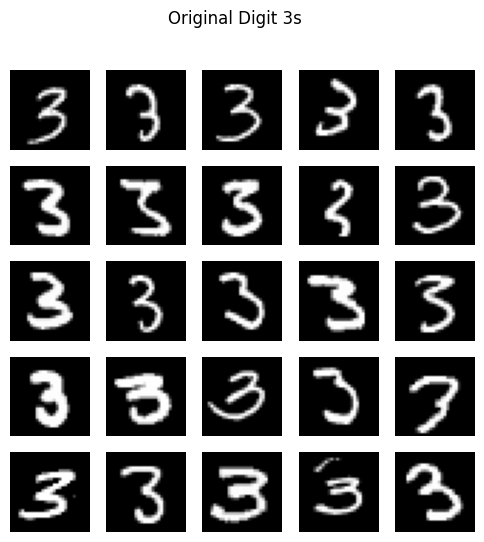

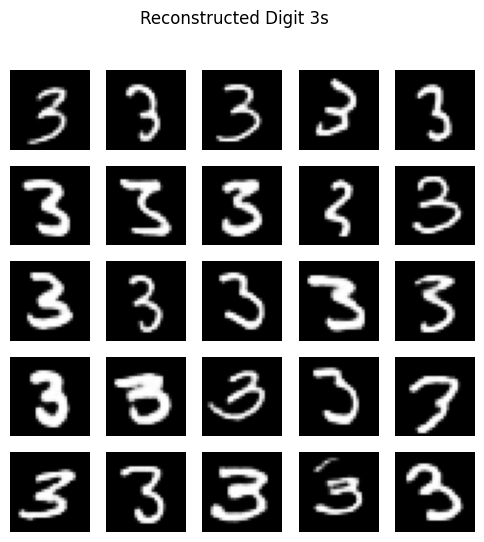

In [8]:
import matplotlib.pyplot as plt

n = 25
sample_idx = rng.choice(len(x_test_3), size=n, replace=False)
orig = x_test_3[sample_idx]
recon = autoencoder.predict(orig)

plt.figure(figsize=(6,6))
for i in range(n):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(orig[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Original Digit 3s")
plt.show()

plt.figure(figsize=(6,6))
for i in range(n):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(recon[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Reconstructed Digit 3s")
plt.show()



Binary Cross Entropy + Sigmoid allowed for stable recovery because the MNIST pixel values were normalized to
0,1
This model is able to reconstruct digits 0, 1, 2, and 4–9 accurately

There is a definite reconstruction loss on the digit 3 because the autoencoder never trained on a 3.

From a visual perspective, the 3s in the reconstructions by 3s retain the same curved two-lobe shape, although they appear blurrier and distorted at times. This is an indication that the convolutional features learnt are able to be generalized to other digits but lack detail for digits not used in learning.